# 10-3-1 Visdom Example

In [1]:
import torch
import torch.nn as nn

import torchvision
import torchvision.datasets as dsets

## import visdom

![](figs/turn_on_terminal.png)

Jupyter Notebook > Terminal 를 새로 켜서 `python -m visdom.server` 를 입력하세요!

In [ ]:
# import visdom
# vis = visdom.Visdom()

In [3]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('logs/mnist_example') # logs 폴더에 기록 저장

## Text

In [ ]:
vis.text("Hello, world!",env="main")

## image

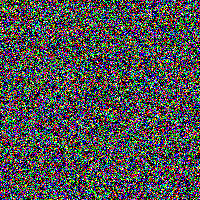

In [4]:
a=torch.randn(3,200,200)
writer.add_image('single_image', a)

## images

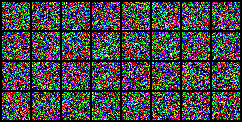

In [ ]:
import torch
import torchvision
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter('logs/test')

value = torch.randn(32, 3, 28, 28) 

# 2. 이제 에러 없이 실행됩니다.
grid = torchvision.utils.make_grid(value) 
writer.add_image('image_batch', grid)

writer.close()

## example (using MNIST and CIFAR10)

In [7]:
# 시간이 좀 걸립니다.
MNIST = dsets.MNIST(root="./MNIST_data",train = True,transform=torchvision.transforms.ToTensor(), download=True)
cifar10 = dsets.CIFAR10(root="./cifar10",train = True, transform=torchvision.transforms.ToTensor(),download=True)

100.0%


#### CIFAR10

In [ ]:
# 데이터를 불러온 후 TensorBoard에 한 장 띄워보기
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('logs/data_check')

# CIFAR10의 첫 번째 이미지 가져오기
img, label = cifar10[0] 
writer.add_image('CIFAR10_Sample', img)
writer.close()

In [ ]:
# data = cifar10.__getitem__(0)
# print(data[0].shape)
# vis.images(data[0],env="main")

#### MNIST

In [11]:
img, label = MNIST[0]
writer.add_image('MNIST_Sample', img)
writer.close()

In [ ]:
# data = MNIST.__getitem__(0)
# print(data[0].shape)
# vis.images(data[0],env="main")

#### Check dataset

In [ ]:
import torchvision
from torch.utils.tensorboard import SummaryWriter

# 1. TensorBoard 기록을 위한 Writer 생성
writer = SummaryWriter('logs/mnist_loader_check')

data_loader 의 구조
- 한 번 호출할 때마다 (이미지 뭉치, 정답 뭉치) 쌍을 던진다.

1. value[0] : 이미지 텐서 (Images)
    - 모양(Shape): [Batch_size, Channel, Height, Width]

    - MNIST 예시: [32, 1, 28, 28]

    - 32: 한 번에 가져온 이미지 장수

    - 1: 흑백 채널 (컬러면 3)

    - 28, 28: 이미지의 가로, 세로 픽셀 크기

2. value[1] : 라벨 텐서 (Labels)
    - 모양(Shape): [Batch_size]

    - MNIST 예시: [32]

    - 내용물: tensor([5, 0, 4, 1, ...]) 처럼 각 이미지의 실제 숫자가 들어있다.

In [12]:
data_loader = torch.utils.data.DataLoader(dataset = MNIST,
                                          batch_size = 32,
                                          shuffle = False)

In [14]:
for num, value in enumerate(data_loader):
    # value[0]에는 이미지 뭉치(Batch)가, value[1]에는 정답(Label)이 들어있다.
    images = value[0]
    
    print(images.shape) # 출력: torch.Size([32, 1, 28, 28])
    
    # 2. 여러 장의 이미지를 격자(Grid) 형태로 만든다.
    grid = torchvision.utils.make_grid(images)
    
    # 3. TensorBoard에 격자 이미지 추가
    writer.add_image('mnist_batch_sample', grid)
    
    # 한 번만 확인하고 루프를 빠져나온다.
    break

torch.Size([32, 1, 28, 28])


## Line Plot

In [15]:
writer = SummaryWriter('logs/line_plots')

In [18]:
Y_data = torch.randn(5)
X_data = torch.Tensor([1, 2, 3, 4, 5])

for i in range(len(Y_data)):
    # TensorBoard는 점을 하나씩 추가하며 선을 잇는다.
    # 'Basic_Line'이라는 차트에 X_data[i] 위치에 Y_data[i] 값을 찍는다.
    writer.add_scalar('Line/Basic', Y_data[i], global_step=int(X_data[i]))

In [ ]:
# Y_data = torch.randn(5)
# plt = vis.line (Y=Y_data)

In [ ]:
# X_data = torch.Tensor([1,2,3,4,5])
# plt = vis.line(Y=Y_data, X=X_data)

### Line update

In [16]:
Y_append = torch.randn(1)
X_append = torch.Tensor([6])

# 기존 'Line/Basic' 태그에 step 6 데이터를 추가하면 자동으로 이어진다.
writer.add_scalar('Line/Basic', Y_append, global_step=int(X_append))

In [ ]:
# Y_append = torch.randn(1)
# X_append = torch.Tensor([6])

# vis.line(Y=Y_append, X=X_append, win=plt, update='append')

### multiple Line on single windows

In [ ]:
for i in range(10):
    val1 = torch.randn(1)
    val2 = torch.randn(1)
    
    # 'Multi_Line'이라는 제목의 차트 안에 'Line_1'과 'Line_2'를 동시에 그린다.
    writer.add_scalars('Line/Multiple', {
        'Line_1': val1,
        'Line_2': val2
    }, global_step=i)

writer.close()
print("TensorBoard 기록 완료")

### Line info

In [ ]:
from torch.utils.tensorboard import SummaryWriter
import torch

writer = SummaryWriter('logs/setting_example')

# 데이터 준비
Y_data = torch.randn(5)
X_data = torch.Tensor([1, 2, 3, 4, 5])

# 1 & 2. 제목 설정 및 단일 범례 (Visdom의 title 및 legend=['1번'])
# TensorBoard에서는 태그 이름을 'Test'로 정하면 그것이 곧 제목이 된다.
for i in range(len(Y_data)):
    # 단일 선의 경우 별도의 legend 설정 없이 태그명이 범례 역할을 겸한다.
    writer.add_scalar('Test/SingleLine', Y_data[i], global_step=int(X_data[i]))


# 3. 다중 선 및 범례 설정 (Visdom의 legend=['1번', '2번'])
# TensorBoard에서는 add_scalars를 사용하고 딕셔너리에 이름을 지정한다.
for i in range(10):
    val1 = torch.randn(1)
    val2 = torch.randn(1)
    
    # 'Test/MultiLine'이 큰 제목이 되고, 딕셔너리의 '1번', '2번'이 각각의 범례가 된다.
    writer.add_scalars('Test/MultiLine', {
        '1번': val1,
        '2번': val2
    }, global_step=i)

writer.close()
print("TensorBoard에 제목과 범례 설정이 완료되었습니다!")

In [ ]:
# plt = vis.line(Y=Y_data, X=X_data, opts = dict(title='Test', showlegend=True))

In [ ]:
# plt = vis.line(Y=Y_data, X=X_data, opts = dict(title='Test', legend = ['1번'],showlegend=True))

In [ ]:
# plt = vis.line(Y=torch.randn(10,2), X = num, opts=dict(title='Test', legend=['1번','2번'],showlegend=True))

## make function for update line

In [ ]:
def loss_tracker(loss_plot, loss_value, num):
    '''num, loss_value, are Tensor'''
    vis.line(X=num,
             Y=loss_value,
             win = loss_plot,
             update='append'
             )

In [ ]:
plt = vis.line(Y=torch.Tensor(1).zero_())

for i in range(500):
    loss = torch.randn(1) + i
    loss_tracker(plt, loss, torch.Tensor([i]))

## close the window

In [ ]:
vis.close(env="main")